Notebook for generating the demonstratory plots in the README.

In [45]:
from quantumthreattracker.lifespan_estimator import HardwareRoadmap

hardware_roadmap = HardwareRoadmap()

for i in range(8):
    max_qubits = int(1e7 * (2**i))
    error_rate = 1e-3 * 0.8**i
    measurement_time = str(100 * 0.9**i) + " ns"
    gate_time = str(50 * 0.9**i) + " ns"
    params = {
        "qubitParams": {
            "name": "Custom",
            "instructionSet": "GateBased",
            "oneQubitMeasurementTime": measurement_time,
            "oneQubitGateTime": gate_time,
            "twoQubitGateTime": gate_time,
            "tGateTime": gate_time,
            "oneQubitMeasurementErrorRate": error_rate,
            "oneQubitGateErrorRate": error_rate,
            "twoQubitGateErrorRate": error_rate,
            "tGateErrorRate": error_rate,
        },
        "constraints": {
            "maxPhysicalQubits": max_qubits
        }
    }
    hardware_roadmap.add(timestamp=2051308800 + 31536000 * 2 * i, estimator_params=params)

In [46]:
from quantumthreattracker.lifespan_estimator import LifespanEstimator

lifespan_estimator = LifespanEstimator(hardware_roadmap)

In [47]:
protocols = [
    {"algorithm": "RSA", "keySize": 1024},
    {"algorithm": "RSA", "keySize": 2048},
    {"algorithm": "RSA", "keySize": 4096},
    {"algorithm": "RSA", "keySize": 8192},
    {"algorithm": "DH-SP", "keySize": 2048},
    {"algorithm": "DH-SP", "keySize": 4096},
    {"algorithm": "DH-SP", "keySize": 8192},
    {"algorithm": "ECDH", "keySize": 256},
    # {"algorithm": "ECDH", "keySize": 384},
    {"algorithm": "ECDH", "keySize": 512},
    ]

In [48]:
lifespan_estimator.generate_report(protocols=protocols, print_progress=True)

Estimating threats for RSA-1024
Estimating threats for RSA-2048
Estimating threats for RSA-4096
Estimating threats for RSA-8192
Estimating threats for DH-SP-2048
Estimating threats for DH-SP-4096
Estimating threats for DH-SP-8192
Estimating threats for ECDH-256
Estimating threats for ECDH-512


In [49]:
lifespan_estimator.get_report(detail_level=1, soonest_threat_only=True)

[{'protocol': 'RSA-1024',
  'threats': [{'timestamp': 2051308800, 'runtime': 11104517428800}]},
 {'protocol': 'RSA-2048',
  'threats': [{'timestamp': 2114380800, 'runtime': 79980435612000}]},
 {'protocol': 'RSA-4096',
  'threats': [{'timestamp': 2177452800, 'runtime': 496748688024420}]},
 {'protocol': 'RSA-8192',
  'threats': [{'timestamp': 2240524800, 'runtime': 2357044050338640}]},
 {'protocol': 'DH-SP-2048',
  'threats': [{'timestamp': 2114380800, 'runtime': 19827909000000}]},
 {'protocol': 'DH-SP-4096',
  'threats': [{'timestamp': 2177452800, 'runtime': 139788085284120}]},
 {'protocol': 'DH-SP-8192',
  'threats': [{'timestamp': 2240524800, 'runtime': 808757968896000}]},
 {'protocol': 'ECDH-256',
  'threats': [{'timestamp': 2051308800, 'runtime': 56530581120000}]},
 {'protocol': 'ECDH-512',
  'threats': [{'timestamp': 2114380800, 'runtime': 259793928918000}]}]

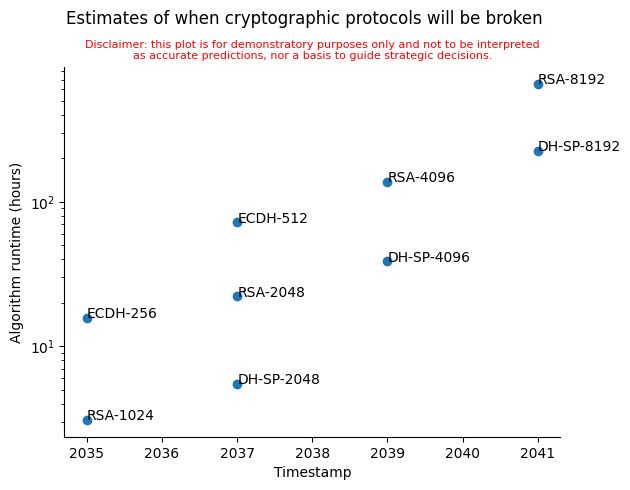

In [50]:
import matplotlib.pyplot as plt

fig = plt.subplots()[0]
ax = lifespan_estimator.plot_threats()
fig.suptitle('Estimates of when cryptographic protocols will be broken', y=1)
ax.set_title('Disclaimer: this plot is for demonstratory purposes only and not to be interpreted\nas ' +
             'accurate predictions, nor a basis to guide strategic decisions.', color='red', size=8)
plt.show()

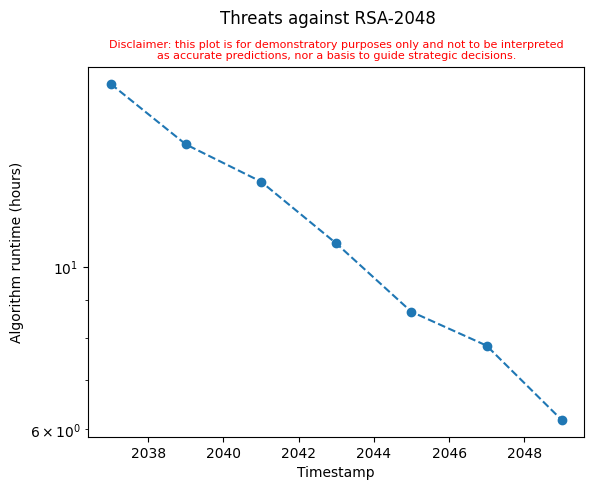

In [51]:
fig = plt.subplots()[0]
ax = lifespan_estimator.plot_threats(protocol="RSA-2048")
fig.suptitle('Threats against RSA-2048', y=1)
ax.set_title('Disclaimer: this plot is for demonstratory purposes only and not to be interpreted\nas ' +
             'accurate predictions, nor a basis to guide strategic decisions.', color='red', size=8)
plt.show()